# Wheat Seed Classification using Machine Learning

This project applies machine learning techniques to classify wheat varieties based on kernel morphological characteristics.

The dataset used in this project was obtained from the UCI Machine Learning Repository and contains real agricultural measurements extracted from wheat kernels.

The study investigates whether measurable kernel traits can accurately distinguish between different wheat cultivars using a Random Forest classifier.

# Importing Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Loading the Dataset
This dataset contains morphological measurements of wheat kernels.

Measured features include:

- Area (A)
- Perimeter (P)
- Compactness (C)
- Kernel Length (LK)
- Kernel Width (WK)
- Asymmetry Coefficient (A_Coef)
- Length of Kernel Groove (LKG)

In [5]:
df = pd.read_csv("Seed_Data.csv")
df.head()

,A,P,C,LK,WK,A_Coef,LKG,target
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,0
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,0
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,0
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,0
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,0


# Preparing Features and Target Variable

In [8]:
X = df.drop(columns=["target"])
y = df["target"]

# Splitting Training and Testing Data

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Training the Random Forest Model

In [10]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

# Model Evaluation

In [11]:
from sklearn.metrics import accuracy_score

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.8809523809523809


In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.71      0.91      0.80        11
           1       1.00      1.00      1.00        14
           2       0.93      0.76      0.84        17

    accuracy                           0.88        42
   macro avg       0.88      0.89      0.88        42
weighted avg       0.90      0.88      0.88        42



The model achieved 88% accuracy in classifying wheat varieties based on morphological features. This suggests that kernel shape and size characteristics carry strong discriminatory information.

# Feature Importance Analysis

In [13]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
0,A,0.204750
6,LKG,0.198793
1,P,0.183721
4,WK,0.171703
3,LK,0.118397
5,A_Coef,0.065346
2,C,0.057289


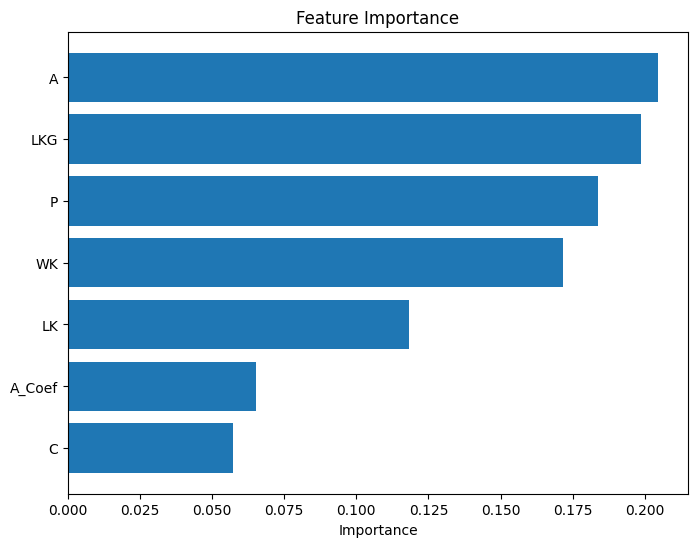

In [14]:

import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(8,6))
plt.barh(importance_df["Feature"], importance_df["Importance"])

plt.xlabel("Importance")
plt.title("Feature Importance")

plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

Feature importance analysis revealed that kernel size-related traits, particularly area and perimeter, are the most influential factors in distinguishing wheat varieties. Structural features such as groove length also play a significant role, while compactness and asymmetry contribute less to classification.

These results suggest that phenotypic variation in wheat varieties is largely driven by size and structural traits, which may reflect underlying genetic differences.

Incorporating genomic features such as SNP markers could further enhance classification by capturing genetic variation beyond morphology.

# Error Analysis

In [15]:
import numpy as np

test_df = X_test.copy()
test_df["y_true"] = y_test.values
test_df["y_pred"] = preds

errors = test_df[test_df["y_true"] != test_df["y_pred"]]
errors

,A,P,C,LK,WK,A_Coef,LKG,y_true,y_pred
199,12.76,13.38,0.8964,5.073,3.155,2.828,4.830,2,0
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,2,0
142,13.34,13.95,0.8620,5.389,3.074,5.995,5.307,2,0
69,12.73,13.75,0.8458,5.412,2.882,3.533,5.067,0,2
197,13.37,13.78,0.8849,5.320,3.128,4.670,5.091,2,0


# Confusion Matrix

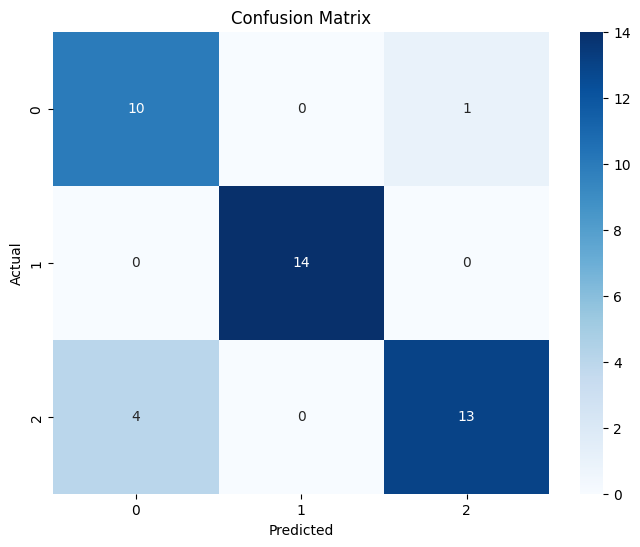

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0,1,2],
            yticklabels=[0,1,2])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

# Biological Interpretation

Feature importance analysis demonstrated that kernel size and structural characteristics played a dominant role in wheat variety classification.

Traits such as kernel area (A), perimeter (P), and length of kernel groove (LKG) contributed the most to model performance, indicating that morphological variability among wheat cultivars carries strong discriminatory information.

In contrast, compactness and asymmetry-related traits showed lower predictive contribution, suggesting weaker differentiation power across wheat classes.

These findings highlight the potential of machine learning approaches for identifying phenotypic differences among wheat varieties based on measurable kernel characteristics.